# RetailPulse

# Demand Forecasting using Time Series Forecasting

---

## Objective

This notebook forecasts future retail sales using historical transaction data.

The objective is to:

- Load the cleaned retail dataset.
- Prepare monthly sales data.
- Train a forecasting model.
- Predict future sales.
- Visualize historical and predicted sales.
- Export forecast results for Streamlit and Power BI dashboards.

---

## Dataset

Input

`../data/cleaned_online_retail.csv`

Outputs

- `../outputs/monthly_sales.csv`
- `../outputs/demand_forecast.csv`

---

Author: Gulafsha

In [32]:
# ==========================================
# Create Monthly Sales Dataset
# ==========================================

monthly_sales = (
    df.groupby(pd.Grouper(key="InvoiceDate", freq="ME"))
      .agg({"Revenue": "sum"})
      .reset_index()
)

monthly_sales.columns = ["Month", "Revenue"]

print("✅ Monthly Sales Dataset Created Successfully")

monthly_sales.head()

✅ Monthly Sales Dataset Created Successfully


,Month,Revenue
0,2009-12-31,822483.950
1,2010-01-31,651155.112
2,2010-02-28,551504.726
3,2010-03-31,830915.261
4,2010-04-30,678875.252


In [33]:
# Save Monthly Sales Dataset

monthly_sales.to_csv(
    "../outputs/monthly_sales.csv",
    index=False
)

print("✅ monthly_sales.csv saved successfully!")

✅ monthly_sales.csv saved successfully!


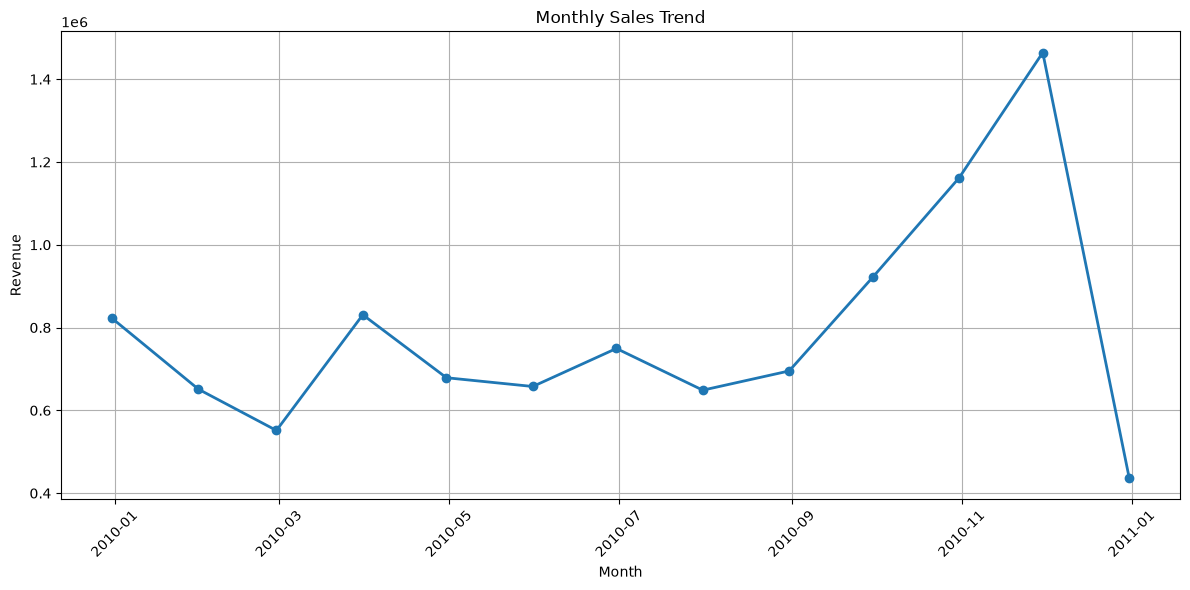

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [29]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

print("Dataset Loaded Successfully ✅")

print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully ✅
Shape: (504730, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


## Prepare Dataset for Prophet

Facebook Prophet requires the input data to have two columns:

- ds → Date
- y → Target variable (Revenue)

The monthly sales dataset is transformed into the required format.

In [36]:
# ==========================================
# Prepare Data for Prophet
# ==========================================

prophet_df = monthly_sales.copy()

prophet_df.columns = ["ds", "y"]

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

print("✅ Prophet Dataset Ready")

prophet_df.head()

✅ Prophet Dataset Ready


,ds,y
0,2009-12-31,822483.950
1,2010-01-31,651155.112
2,2010-02-28,551504.726
3,2010-03-31,830915.261
4,2010-04-30,678875.252


## Train the Forecasting Model

The Prophet forecasting model is trained using the historical monthly sales data.

Prophet automatically models:

- Trend
- Seasonality
- Holidays (if provided)

In [37]:
# ==========================================
# Train Prophet Model
# ==========================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

print("✅ Prophet Model Trained Successfully")

19:58:42 - cmdstanpy - INFO - Chain [1] start processing
19:58:42 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet Model Trained Successfully


## Forecast Future Sales

The trained model predicts the next 12 months of retail sales.

In [38]:
# ==========================================
# Forecast Next 12 Months
# ==========================================

future = model.make_future_dataframe(
    periods=12,
    freq="ME"
)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-31,1.013703e+06,822483.750137,822483.751798,1.013703e+06,1.013703e+06,-191218.803964,-191218.803964,-191218.803964,-191218.803964,-191218.803964,-191218.803964,0.0,0.0,0.0,822483.750960
1,2010-01-31,1.071595e+06,651155.149068,651155.150690,1.071595e+06,1.071595e+06,-420440.118327,-420440.118327,-420440.118327,-420440.118327,-420440.118327,-420440.118327,0.0,0.0,0.0,651155.149849
2,2010-02-28,1.123885e+06,551504.708947,551504.710677,1.123885e+06,1.123885e+06,-572380.751165,-572380.751165,-572380.751165,-572380.751165,-572380.751165,-572380.751165,0.0,0.0,0.0,551504.709862
3,2010-03-31,1.181778e+06,830915.323054,830915.324629,1.181778e+06,1.181778e+06,-350862.850657,-350862.850657,-350862.850657,-350862.850657,-350862.850657,-350862.850657,0.0,0.0,0.0,830915.323833
4,2010-04-30,1.237803e+06,678875.255876,678875.257542,1.237803e+06,1.237803e+06,-558928.124322,-558928.124322,-558928.124322,-558928.124322,-558928.124322,-558928.124322,0.0,0.0,0.0,678875.256717


## Forecast Visualization

The chart below compares historical sales with predicted future sales.

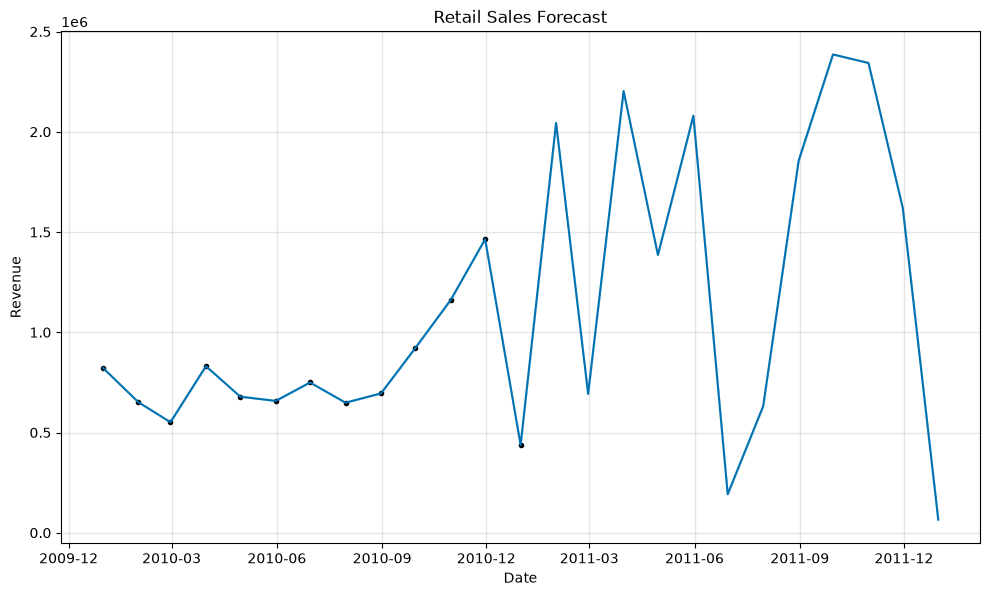

In [39]:
fig = model.plot(forecast)

plt.title("Retail Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

In [40]:
forecast_output = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_output.to_csv(
    "../outputs/demand_forecast.csv",
    index=False
)

print("✅ demand_forecast.csv saved successfully!")

✅ demand_forecast.csv saved successfully!


In [42]:
import pickle
import os

# Create models folder in main project (one level up)
os.makedirs("../models", exist_ok=True)

# Save Prophet model
with open("../models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Prophet model saved in RetailPulse/models/")

✅ Prophet model saved in RetailPulse/models/


# Business Insights

### Key Observations

- Monthly sales follow a clear trend over time.
- Prophet predicts the next 12 months using historical purchasing behaviour.
- Seasonal fluctuations indicate peak sales periods.
- Forecasts help management prepare inventory levels.
- Marketing campaigns can be scheduled before expected demand peaks.
- Procurement teams can reduce stock shortages using forecasted demand.

# Conclusion

Demand Forecasting successfully predicts future retail sales using the Prophet time-series model.

This forecasting pipeline can be integrated into:

- Power BI
- Streamlit Dashboard
- Inventory Optimization
- Business Planning

The generated forecast dataset is exported for downstream analytics and visualization.